<a href="https://colab.research.google.com/github/colynestores4-gif/COLYN-ESTORES/blob/main/Estores_activity_01_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
iris = load_iris()

In [ ]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [ ]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names



)

df["species"] = iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

number of rows: 150
number of columns: 5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
print(df["species"]. unique())

['setosa' 'versicolor' 'virginica']


In [ ]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


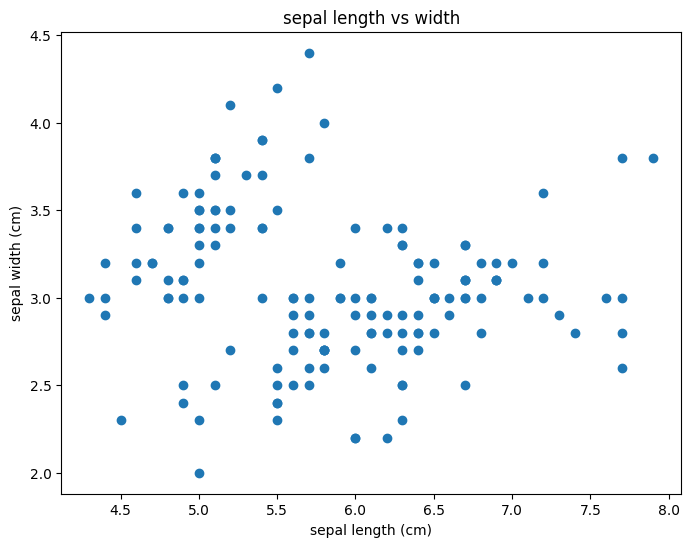

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["sepal length (cm)"],
    df["sepal width (cm)"]


)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("sepal length vs width")

plt.show()

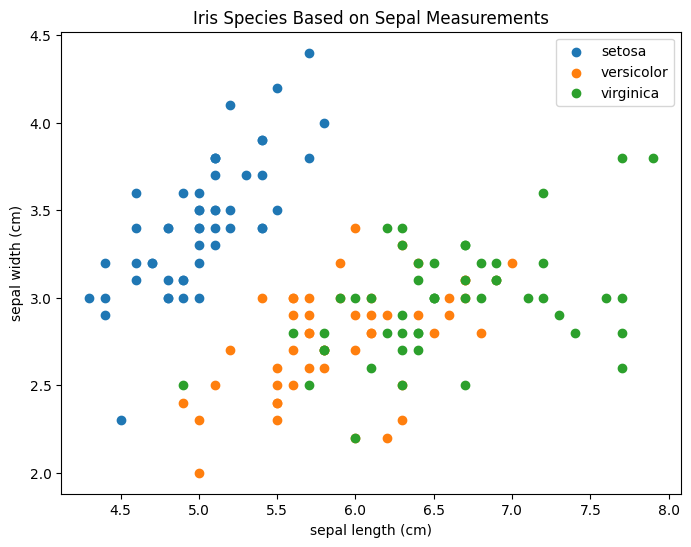

In [ ]:
plt.figure(figsize=(8,6))

for species in df["species"].unique():
  subset = df[df["species"]==species]

  plt.scatter(
      subset["sepal length (cm)"],
      subset["sepal width (cm)"],
      label = species

  )

  plt.xlabel("sepal length (cm)")
  plt.ylabel("sepal width (cm)")
  plt.title("Iris Species Based on Sepal Measurements")
  plt.legend()

  plt.show

In [ ]:
x = iris.data
y = iris.target

In [ ]:
x_train, x_test, y_train, y_test =train_test_split(
     x,
     y,
     test_size=0.20,
     random_state=42,
     stratify=y
 )

print("Training obsevations: ", len(x_train))
print("Training obsevations: ", len(x_test))

Training obsevations:  120
Training obsevations:  30


In [ ]:
model = KNeighborsClassifier(n_neighbors=3)

In [ ]:
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
print("Actual: ")
print(y_test)

print("\nPredicted: ")
print(y_pred)

Actual: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  1.0


In [ ]:
new_flower =[[5.1, 3.5, 1.4, 0.2]]

In [ ]:
prediction=model.predict(new_flower)

In [ ]:
print(
    "Prediction: ",
    iris.target_names[prediction[0]]
)

Prediction:  setosa


In [ ]:
probabilities = model.predict_proba(new_flower)
print(probabilities)

[[1. 0. 0.]]


In [ ]:
for species, probability in zip(
    iris.target_names,
    probabilities[0]

):
  print(f"{species}: {probability:2%}")


setosa: 100.000000%
versicolor: 0.000000%
virginica: 0.000000%


In [ ]:
k_values = [1,3,5,7,9]
accuracies = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
  print(f"k={k}, Accuracy={accuracy:2f}")


k=1, Accuracy=0.966667
k=3, Accuracy=1.000000
k=5, Accuracy=1.000000
k=7, Accuracy=0.966667
k=9, Accuracy=1.000000


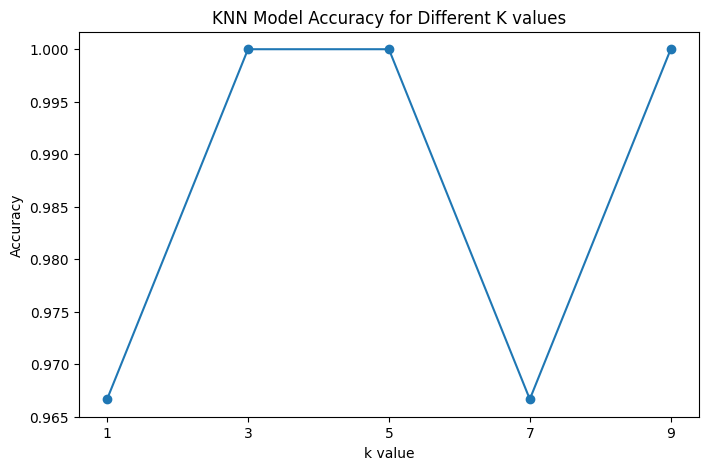

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("KNN Model Accuracy for Different K values")

plt.xticks(k_values)
plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual":iris.target_names[y_test],
    "Predicted":iris.target_names[y_pred]
})

results.head(10)


,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor
